# Front-bearing rolling-element fault validation

This notebook validates the front_ball condition as a rolling-element fault using the time- and frequency-domain approach in Cheng et al., *Research on ball bearing model based on local defects*, SN Applied Sciences (2019), DOI: 10.1007/s42452-019-1251-4. The paper predicts repeated impacts at twice the ball-spin frequency (2 x BSF), with harmonics and cage-frequency sidebands. Here, the prediction is compared with front-bearing vibration recordings and matched healthy references.

The analysis uses two clean laboratory-supply recordings at 1500 rpm and 128 mA: motor 2, run at 1500 rpm (ID 20), and motor 3, run at 1500 rpm (ID 30). This high-load, mid-range speed condition is expected to give a stable shaft speed and a clear rolling-element response without relying on the supplementary high-speed data. Motor 3 has the strongest fault/reference contrast; motor 2 provides an independent repeat. Files marked ENV or SF are deliberately excluded.


In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal
from scipy.stats import kurtosis

plt.style.use('seaborn-v0_8-whitegrid')


## Configuration and bearing-frequency model

The repository identifies the front bearing as a 608ZZ (8 x 22 x 7 mm) and records ax, ay, and az on its bearing ring. Detailed internal 608ZZ geometry is not stored with the dataset, so the characteristic-frequency calculation uses a documented engineering estimate for a common 608ZZ: seven 3.969 mm balls on a 15.0 mm pitch diameter at zero contact angle. Replace these values with the measured bearing geometry if it becomes available.

Following the article, the outer race is treated as fixed and the inner race as rotating. The rolling-element signature is 2 x BSF because a ball defect can strike the inner and outer race once each per ball rotation. The actual shaft speed is estimated from the pg_rpm tachometer signal, using the documented six pulses per mechanical revolution.


In [18]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'

RECORDINGS = (
    {
        'label': 'Motor 2, run at 1500 rpm',
        'fault_file': 'analize_front_ball20_1500rpm_128mA_mait.csv',
        'healthy_file': 'analize_healthy20_1500rpm_128mA_mait.csv',
    },
    {
        'label': 'Motor 3, run at 1500 rpm',
        'fault_file': 'analize_front_ball30_1500rpm_128mA_mait.csv',
        'healthy_file': 'analize_healthy30_1500rpm_128mA_mait.csv',
    },
)

PULSES_PER_REVOLUTION = 6
BALL_COUNT = 7
BALL_DIAMETER_MM = 3.969
PITCH_DIAMETER_MM = 15.0
CONTACT_ANGLE_DEG = 0.0
SETTLE_SECONDS = 10
ANALYSIS_SECONDS = 45
ENVELOPE_BAND_HZ = (120.0, 400.0)

for recording in RECORDINGS:
    for kind in ('fault_file', 'healthy_file'):
        path = DATA_DIR / recording[kind]
        if not path.is_file():
            raise FileNotFoundError(path)


In [19]:
def load_recording(filename):
    frame = pd.read_csv(DATA_DIR / filename)
    time_s = frame['t_us'].to_numpy(dtype=float) * 1e-6
    sample_rate_hz = 1.0 / np.median(np.diff(time_s))
    return frame, time_s, sample_rate_hz


def tachometer_rpm(frame, time_s):
    pulses = frame['pg_rpm'].to_numpy(dtype=int)
    rising_edges = np.count_nonzero((pulses[1:] == 1) & (pulses[:-1] == 0))
    duration_s = time_s[-1] - time_s[0]
    return 60.0 * rising_edges / (PULSES_PER_REVOLUTION * duration_s)


def one_shaft_revolution(frame, time_s, axis):
    pulses = frame['pg_rpm'].to_numpy(dtype=int)
    rising_edges = np.flatnonzero((pulses[1:] == 1) & (pulses[:-1] == 0)) + 1
    steady_edges = rising_edges[time_s[rising_edges] >= time_s[0] + SETTLE_SECONDS]
    if len(steady_edges) < PULSES_PER_REVOLUTION + 1:
        raise ValueError('The recording does not contain a complete shaft revolution after settling.')
    revolution_periods = time_s[steady_edges[PULSES_PER_REVOLUTION:]] - time_s[steady_edges[:-PULSES_PER_REVOLUTION]]
    start_edge = np.argmin(np.abs(revolution_periods - np.median(revolution_periods)))
    start = steady_edges[start_edge]
    stop = steady_edges[start_edge + PULSES_PER_REVOLUTION] + 1
    values = signal.detrend(frame[axis].to_numpy(dtype=float)[start:stop])
    return time_s[start:stop] - time_s[start], values


def bearing_frequencies(shaft_rpm):
    shaft_hz = shaft_rpm / 60.0
    diameter_ratio = BALL_DIAMETER_MM / PITCH_DIAMETER_MM
    cos_alpha = np.cos(np.deg2rad(CONTACT_ANGLE_DEG))
    ftf_hz = 0.5 * shaft_hz * (1.0 - diameter_ratio * cos_alpha)
    bsf_hz = 0.5 * (PITCH_DIAMETER_MM / BALL_DIAMETER_MM) * shaft_hz * (1.0 - (diameter_ratio * cos_alpha) ** 2)
    return {'shaft_hz': shaft_hz, 'ftf_hz': ftf_hz, 'bsf_hz': bsf_hz, 'two_bsf_hz': 2.0 * bsf_hz}


def steady_segment(frame, time_s, sample_rate_hz, axis):
    start = int(SETTLE_SECONDS * sample_rate_hz)
    stop = min(len(frame), start + int(ANALYSIS_SECONDS * sample_rate_hz))
    values = signal.detrend(frame[axis].to_numpy(dtype=float)[start:stop])
    return time_s[start:stop] - time_s[start], values


def amplitude_spectrum(values, sample_rate_hz):
    window = signal.windows.hann(len(values), sym=False)
    amplitude = np.abs(np.fft.rfft(values * window)) * 2.0 / window.sum()
    frequency_hz = np.fft.rfftfreq(len(values), d=1.0 / sample_rate_hz)
    return frequency_hz, amplitude


def envelope_spectrum(values, sample_rate_hz, band_hz=ENVELOPE_BAND_HZ):
    sos = signal.butter(4, band_hz, btype='bandpass', fs=sample_rate_hz, output='sos')
    carrier = signal.sosfiltfilt(sos, values)
    envelope = signal.detrend(np.abs(signal.hilbert(carrier)))
    return amplitude_spectrum(envelope, sample_rate_hz)


def local_peak(frequency_hz, amplitude, centre_hz, half_width_hz=3.0):
    in_band = (frequency_hz >= centre_hz - half_width_hz) & (frequency_hz <= centre_hz + half_width_hz)
    band_indices = np.flatnonzero(in_band)
    peak_index = band_indices[np.argmax(amplitude[band_indices])]
    return frequency_hz[peak_index], amplitude[peak_index]


In [20]:
axis_rows = []
for recording in RECORDINGS:
    fault_frame, _, _ = load_recording(recording['fault_file'])
    healthy_frame, _, _ = load_recording(recording['healthy_file'])
    for axis in ('ax', 'ay', 'az'):
        fault_rms = np.std(signal.detrend(fault_frame[axis].to_numpy(dtype=float)))
        healthy_rms = np.std(signal.detrend(healthy_frame[axis].to_numpy(dtype=float)))
        axis_rows.append({'run': recording['label'], 'axis': axis, 'rms_ratio': fault_rms / healthy_rms})

axis_contrast = pd.DataFrame(axis_rows)
axis_summary = axis_contrast.groupby('axis')['rms_ratio'].median().sort_values(ascending=False)
ANALYSIS_AXIS = axis_summary.index[0]
display(axis_summary.to_frame('median fault-to-healthy RMS ratio'))
print(f'Using {ANALYSIS_AXIS} from the front-bearing accelerometer.')


,median fault-to-healthy RMS ratio
axis,
ay,3.125469
az,2.377556
ax,1.155008


Using ay from the front-bearing accelerometer.


,recording,shaft rpm,shaft Hz,FTF Hz,2 x BSF predicted Hz,2 x BSF local peak Hz,peak error Hz,fault/reference contrast dB,fault kurtosis,healthy kurtosis
0,analize_front_ball20_1500rpm_128mA_mait.csv,1507.99,25.13,9.24,88.34,90.69,2.35,21.45,3.76,2.75
1,analize_front_ball30_1500rpm_128mA_mait.csv,1511.02,25.18,9.26,88.51,87.18,-1.33,26.42,6.15,3.75


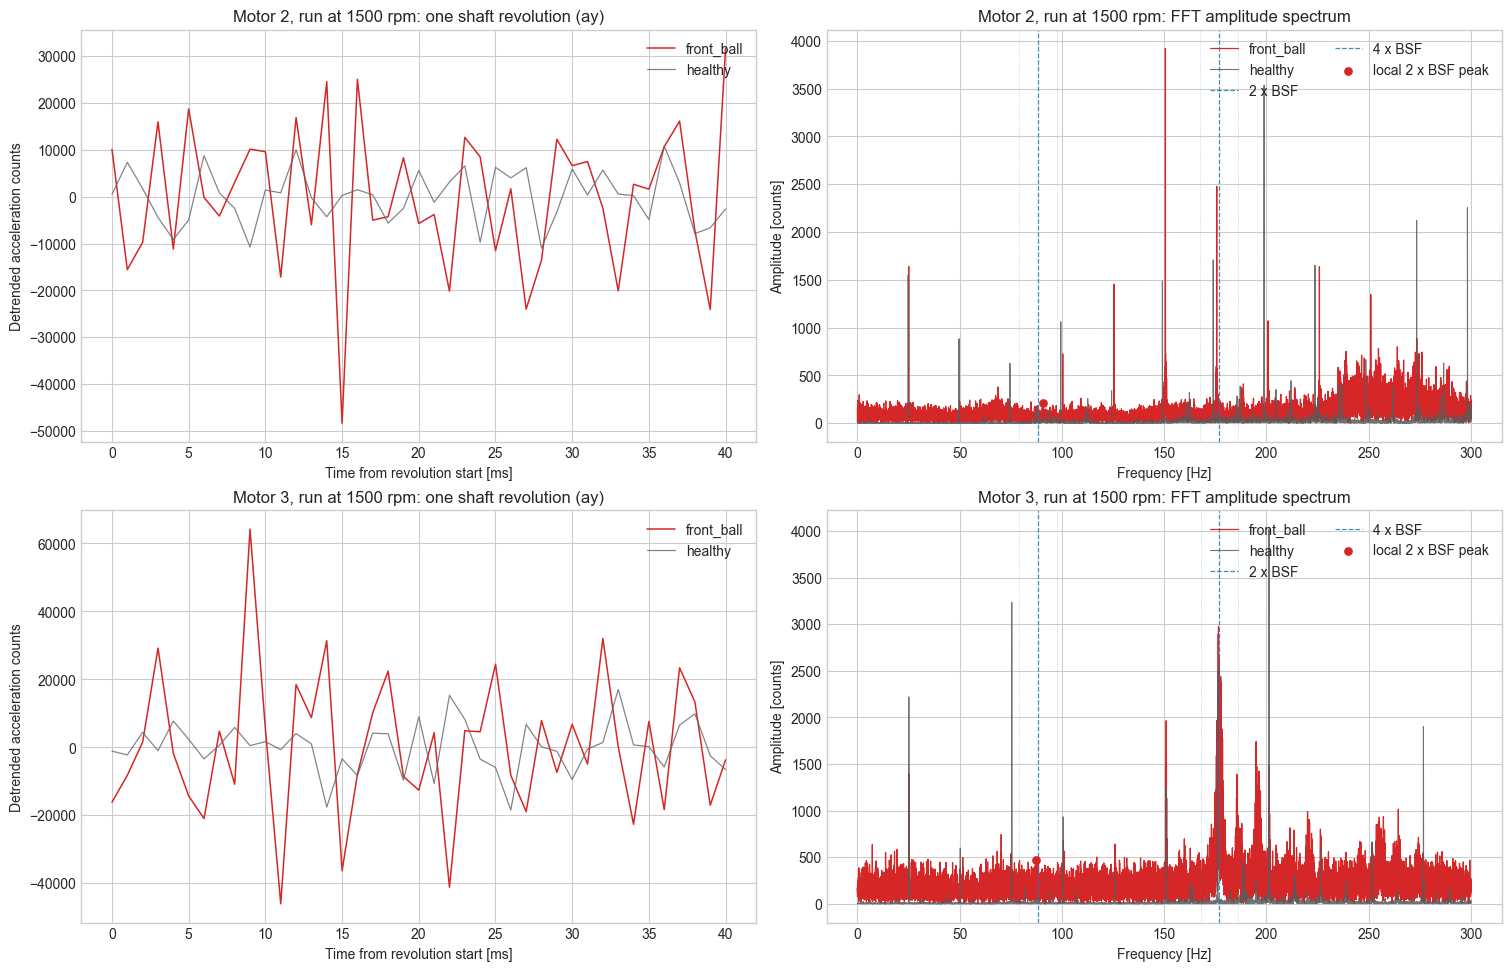

In [21]:
fig, axes = plt.subplots(len(RECORDINGS), 2, figsize=(15, 4.8 * len(RECORDINGS)), constrained_layout=True)
if len(RECORDINGS) == 1:
    axes = np.asarray([axes])

results = []
for row, recording in enumerate(RECORDINGS):
    fault_frame, fault_time_s, fault_fs = load_recording(recording['fault_file'])
    healthy_frame, healthy_time_s, healthy_fs = load_recording(recording['healthy_file'])
    fault_rpm = tachometer_rpm(fault_frame, fault_time_s)
    frequencies = bearing_frequencies(fault_rpm)

    fault_segment_time, fault_values = steady_segment(fault_frame, fault_time_s, fault_fs, ANALYSIS_AXIS)
    healthy_segment_time, healthy_values = steady_segment(healthy_frame, healthy_time_s, healthy_fs, ANALYSIS_AXIS)
    fault_frequency_hz, fault_amplitude = amplitude_spectrum(fault_values, fault_fs)
    healthy_frequency_hz, healthy_amplitude = amplitude_spectrum(healthy_values, healthy_fs)

    expected_hz = frequencies['two_bsf_hz']
    observed_hz, fault_peak = local_peak(fault_frequency_hz, fault_amplitude, expected_hz)
    healthy_at_peak = np.interp(observed_hz, healthy_frequency_hz, healthy_amplitude)
    contrast_db = 20.0 * np.log10((fault_peak + np.finfo(float).eps) / (healthy_at_peak + np.finfo(float).eps))
    results.append({
        'recording': recording['fault_file'],
        'shaft rpm': fault_rpm,
        'shaft Hz': frequencies['shaft_hz'],
        'FTF Hz': frequencies['ftf_hz'],
        '2 x BSF predicted Hz': expected_hz,
        '2 x BSF local peak Hz': observed_hz,
        'peak error Hz': observed_hz - expected_hz,
        'fault/reference contrast dB': contrast_db,
        'fault kurtosis': kurtosis(fault_values, fisher=False),
        'healthy kurtosis': kurtosis(healthy_values, fisher=False),
    })

    fault_revolution_time, fault_revolution_values = one_shaft_revolution(fault_frame, fault_time_s, ANALYSIS_AXIS)
    healthy_revolution_time, healthy_revolution_values = one_shaft_revolution(healthy_frame, healthy_time_s, ANALYSIS_AXIS)
    time_axis = axes[row, 0]
    time_axis.plot(fault_revolution_time * 1e3, fault_revolution_values, color='tab:red', lw=1.1, label='front_ball')
    time_axis.plot(healthy_revolution_time * 1e3, healthy_revolution_values, color='0.4', lw=0.9, alpha=0.8, label='healthy')
    time_axis.set(title=f'{recording['label']}: one shaft revolution ({ANALYSIS_AXIS})', xlabel='Time from revolution start [ms]', ylabel='Detrended acceleration counts')
    time_axis.legend(loc='upper right')

    spectrum_axis = axes[row, 1]
    visible = fault_frequency_hz <= 300
    spectrum_axis.plot(fault_frequency_hz[visible], fault_amplitude[visible], color='tab:red', lw=0.9, label='front_ball')
    spectrum_axis.plot(healthy_frequency_hz[healthy_frequency_hz <= 300], healthy_amplitude[healthy_frequency_hz <= 300], color='0.35', lw=0.8, alpha=0.85, label='healthy')
    for harmonic in (1, 2):
        feature_hz = harmonic * expected_hz
        spectrum_axis.axvline(feature_hz, color='tab:blue', lw=0.9, ls='--', alpha=0.85, label='2 x BSF' if harmonic == 1 else '4 x BSF')
        for side in (-1, 1):
            spectrum_axis.axvline(feature_hz + side * frequencies['ftf_hz'], color='tab:blue', lw=0.6, ls=':', alpha=0.35)
    spectrum_axis.scatter(observed_hz, fault_peak, color='tab:red', s=28, zorder=3, label='local 2 x BSF peak')
    spectrum_axis.set(title=f'{recording['label']}: FFT amplitude spectrum', xlabel='Frequency [Hz]', ylabel='Amplitude [counts]')
    spectrum_axis.legend(loc='upper right', ncol=2)

results_table = pd.DataFrame(results)
display(results_table.round(2))


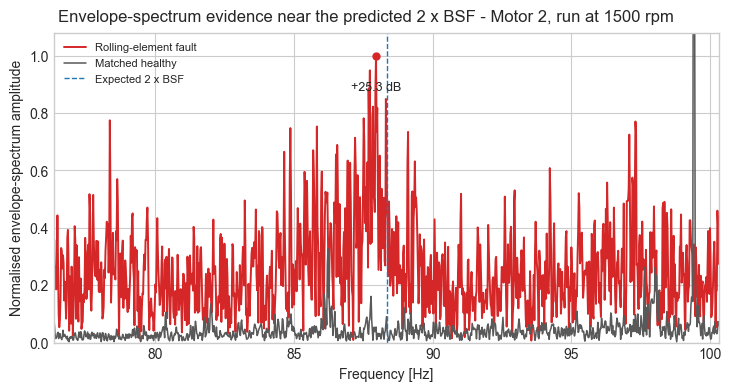

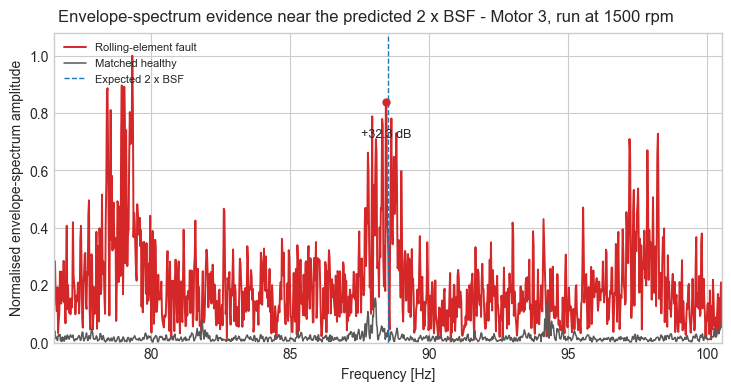

,recording,2 x BSF predicted Hz,envelope peak Hz,envelope peak error Hz,envelope contrast dB
0,analize_front_ball20_1500rpm_128mA_mait.csv,88.34,87.96,-0.38,25.28
1,analize_front_ball30_1500rpm_128mA_mait.csv,88.51,88.44,-0.07,32.26


In [22]:
for row, (recording, result) in enumerate(zip(RECORDINGS, results)):
    fig, axis = plt.subplots(figsize=(7.2, 3.8), constrained_layout=True)
    fault_frame, fault_time_s, fault_fs = load_recording(recording['fault_file'])
    healthy_frame, healthy_time_s, healthy_fs = load_recording(recording['healthy_file'])
    _, fault_values = steady_segment(fault_frame, fault_time_s, fault_fs, ANALYSIS_AXIS)
    _, healthy_values = steady_segment(healthy_frame, healthy_time_s, healthy_fs, ANALYSIS_AXIS)
    fault_frequency_hz, fault_amplitude = envelope_spectrum(fault_values, fault_fs)
    healthy_frequency_hz, healthy_amplitude = envelope_spectrum(healthy_values, healthy_fs)

    predicted_hz = result['2 x BSF predicted Hz']
    focus = (fault_frequency_hz >= predicted_hz - 12.0) & (fault_frequency_hz <= predicted_hz + 12.0)
    fault_normaliser = fault_amplitude[focus].max()
    healthy_on_fault_grid = np.interp(fault_frequency_hz[focus], healthy_frequency_hz, healthy_amplitude)
    observed_hz, fault_peak = local_peak(fault_frequency_hz, fault_amplitude, predicted_hz)
    healthy_at_peak = np.interp(observed_hz, healthy_frequency_hz, healthy_amplitude)
    contrast_db = 20.0 * np.log10((fault_peak + np.finfo(float).eps) / (healthy_at_peak + np.finfo(float).eps))

    axis.plot(fault_frequency_hz[focus], fault_amplitude[focus] / fault_normaliser, color='tab:red', lw=1.4, label='Rolling-element fault')
    axis.plot(fault_frequency_hz[focus], healthy_on_fault_grid / fault_normaliser, color='0.35', lw=1.1, label='Matched healthy')
    axis.axvline(predicted_hz, color='tab:blue', lw=1.0, ls='--', label='Expected 2 x BSF')
    axis.plot(observed_hz, fault_peak / fault_normaliser, marker='o', ms=5, color='tab:red')
    axis.annotate(f'+{contrast_db:.1f} dB', xy=(observed_hz, fault_peak / fault_normaliser), xytext=(0, -25), textcoords='offset points', ha='center', fontsize=9)
    axis.set(xlabel='Frequency [Hz]', ylabel='Normalised envelope-spectrum amplitude', xlim=(predicted_hz - 12.0, predicted_hz + 12.0), ylim=(0, 1.08))
    results[row]['envelope peak Hz'] = observed_hz
    results[row]['envelope peak error Hz'] = observed_hz - predicted_hz
    results[row]['envelope contrast dB'] = contrast_db
    axis.legend(loc='upper left', frameon=False, fontsize=8)
    fig.suptitle('Envelope-spectrum evidence near the predicted 2 x BSF - ' + recording['label'], fontsize=12)
    plt.show()

envelope_results = pd.DataFrame(results)[['recording', '2 x BSF predicted Hz', 'envelope peak Hz', 'envelope peak error Hz', 'envelope contrast dB']]
display(envelope_results.round(2))


## Supporting 1 x to 4 x BSF harmonics

The article expects frequency doublings for a rolling-element defect. This separate, focused envelope-spectrum figure tests the first harmonic, 4 x BSF, with exactly the same 120–400 Hz filter, healthy controls, and local-peak tolerance as the primary 2 x BSF figure. It is supporting evidence rather than a replacement for the primary frequency.


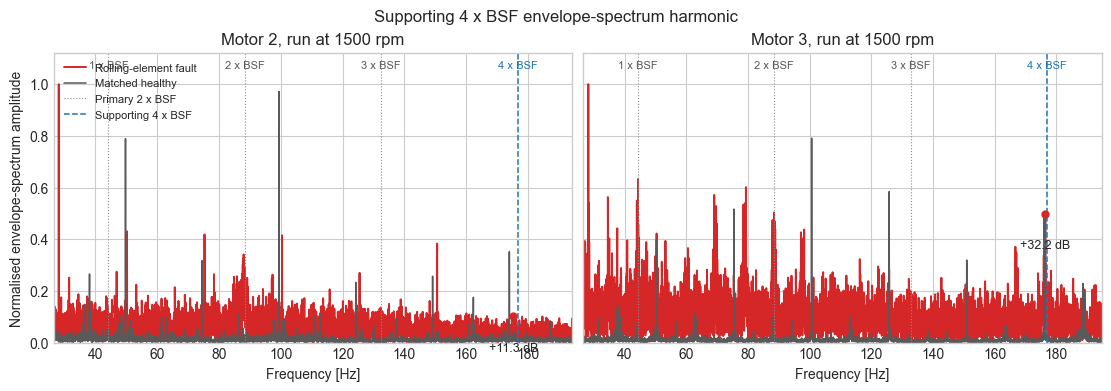

,recording,4 x BSF predicted Hz,4 x BSF peak Hz,4 x BSF peak error Hz,4 x BSF contrast dB
0,analize_front_ball20_1500rpm_128mA_mait.csv,176.67,175.27,-1.40,11.26
1,analize_front_ball30_1500rpm_128mA_mait.csv,177.03,176.44,-0.58,32.20


In [23]:
fig, harmonic_axes = plt.subplots(1, len(RECORDINGS), figsize=(11, 3.8), sharey=True, constrained_layout=True)
if len(RECORDINGS) == 1:
    harmonic_axes = [harmonic_axes]

four_bsf_rows = []
for axis, recording, result in zip(harmonic_axes, RECORDINGS, results):
    fault_frame, fault_time_s, fault_fs = load_recording(recording['fault_file'])
    healthy_frame, healthy_time_s, healthy_fs = load_recording(recording['healthy_file'])
    _, fault_values = steady_segment(fault_frame, fault_time_s, fault_fs, ANALYSIS_AXIS)
    _, healthy_values = steady_segment(healthy_frame, healthy_time_s, healthy_fs, ANALYSIS_AXIS)
    fault_frequency_hz, fault_amplitude = envelope_spectrum(fault_values, fault_fs)
    healthy_frequency_hz, healthy_amplitude = envelope_spectrum(healthy_values, healthy_fs)

    bsf_hz = result['2 x BSF predicted Hz'] / 2.0
    predicted_hz = 4.0 * bsf_hz
    observed_hz, fault_peak = local_peak(fault_frequency_hz, fault_amplitude, predicted_hz)
    healthy_at_peak = np.interp(observed_hz, healthy_frequency_hz, healthy_amplitude)
    contrast_db = 20.0 * np.log10((fault_peak + np.finfo(float).eps) / (healthy_at_peak + np.finfo(float).eps))
    view = (fault_frequency_hz >= 0.6 * bsf_hz) & (fault_frequency_hz <= 4.4 * bsf_hz)
    fault_normaliser = fault_amplitude[view].max()
    healthy_on_fault_grid = np.interp(fault_frequency_hz[view], healthy_frequency_hz, healthy_amplitude)

    axis.plot(fault_frequency_hz[view], fault_amplitude[view] / fault_normaliser, color='tab:red', lw=1.4, label='Rolling-element fault')
    axis.plot(fault_frequency_hz[view], healthy_on_fault_grid / fault_normaliser, color='0.35', lw=1.1, label='Matched healthy')
    for order in range(1, 5):
        feature_hz = order * bsf_hz
        is_primary = order == 2
        is_harmonic = order == 4
        axis.axvline(feature_hz, color='tab:blue' if is_harmonic else '0.55', lw=1.1 if is_harmonic else 0.8, ls='--' if is_harmonic else ':', label='Supporting 4 x BSF' if is_harmonic else ('Primary 2 x BSF' if is_primary else None))
        axis.text(feature_hz, 1.055, f'{order} x BSF', ha='center', va='bottom', fontsize=8, color='tab:blue' if is_harmonic else '0.35')
    axis.plot(observed_hz, fault_peak / fault_normaliser, marker='o', ms=5, color='tab:red')
    axis.annotate(f'+{contrast_db:.1f} dB', xy=(observed_hz, fault_peak / fault_normaliser), xytext=(0, -25), textcoords='offset points', ha='center', fontsize=9)
    axis.set(title=recording['label'], xlabel='Frequency [Hz]', xlim=(0.6 * bsf_hz, 4.4 * bsf_hz), ylim=(0, 1.12))
    four_bsf_rows.append({
        'recording': recording['fault_file'],
        '4 x BSF predicted Hz': predicted_hz,
        '4 x BSF peak Hz': observed_hz,
        '4 x BSF peak error Hz': observed_hz - predicted_hz,
        '4 x BSF contrast dB': contrast_db,
    })

harmonic_axes[0].set_ylabel('Normalised envelope-spectrum amplitude')
harmonic_axes[0].legend(loc='upper left', frameon=False, fontsize=8)
fig.suptitle('Supporting 4 x BSF envelope-spectrum harmonic', fontsize=12)
plt.show()

four_bsf_results = pd.DataFrame(four_bsf_rows)
display(four_bsf_results.round(2))
